In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 10000

# -------------------------
# Borrower Demographics
# -------------------------

age = np.random.randint(21, 60, n)

monthly_income = np.random.normal(50000, 15000, n)
monthly_income = np.clip(monthly_income, 15000, None)

employment_type = np.random.choice(
    ["salaried", "self_employed"],
    size=n,
    p=[0.7, 0.3]
)

years_at_job = np.random.randint(0, 15, n)

city_tier = np.random.choice(
    ["metro", "tier2", "tier3"],
    size=n,
    p=[0.4, 0.4, 0.2]
)

# -------------------------
# Bureau Behaviour
# -------------------------

bureau_score = np.random.normal(700, 60, n)
bureau_score = np.clip(bureau_score, 500, 850)

num_active_loans = np.random.poisson(2, n)

past_dpd_30 = np.random.poisson(0.5, n)

credit_utilization = np.random.beta(2, 5, n)

# -------------------------
# Loan Characteristics
# -------------------------

loan_amount = np.random.normal(200000, 80000, n)
loan_amount = np.clip(loan_amount, 20000, None)

interest_rate = np.random.normal(14, 2, n)

tenure_months = np.random.choice(
    [12, 24, 36, 48],
    size=n
)

# EMI calculation
emi = loan_amount / tenure_months + (loan_amount * interest_rate / 100 / 12)

# -------------------------
# Derived Features
# -------------------------

foir = emi / monthly_income
loan_to_income = loan_amount / (monthly_income * 12)

loan_id = ["LN" + str(i).zfill(6) for i in range(1, n+1)]

# -------------------------
# Create DataFrame
# -------------------------

df = pd.DataFrame({
    "loan_id": loan_id,
    "age": age,
    "monthly_income": monthly_income,
    "employment_type": employment_type,
    "years_at_job": years_at_job,
    "city_tier": city_tier,
    "bureau_score": bureau_score,
    "num_active_loans": num_active_loans,
    "past_dpd_30": past_dpd_30,
    "credit_utilization": credit_utilization,
    "loan_amount": loan_amount,
    "interest_rate": interest_rate,
    "tenure_months": tenure_months,
    "emi": emi,
    "foir": foir,
    "loan_to_income": loan_to_income
})

In [2]:
df.head()

,loan_id,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,credit_utilization,loan_amount,interest_rate,tenure_months,emi,foir,loan_to_income
0,LN000001,59,77313.480137,salaried,10,tier2,678.170368,0,0,0.593077,244688.955675,15.529005,48,8264.166645,0.106892,0.263741
1,LN000002,49,59969.582444,self_employed,12,tier2,623.669208,3,1,0.232975,112084.839190,14.070688,12,10654.662280,0.177668,0.155752
2,LN000003,35,46684.333284,self_employed,10,tier2,783.246960,2,0,0.029162,246468.771643,16.045854,24,13565.200341,0.290573,0.439956
3,LN000004,28,36239.505063,salaried,2,metro,643.954801,2,1,0.195198,188027.588863,14.860045,12,17997.381050,0.496623,0.432373
4,LN000005,41,44668.829138,salaried,1,tier2,696.991839,0,0,0.033303,304194.041438,11.097440,24,15487.897565,0.346727,0.567499


In [3]:
risk_score = (
    (700 - df["bureau_score"]) * 0.005 +
    df["foir"] * 4 +
    df["past_dpd_30"] * 1.2 +
    df["credit_utilization"] * 2 +
    (df["employment_type"] == "self_employed") * 0.8
)

prob_default = 1 / (1 + np.exp(-(risk_score - 3)))

df["FPD_FLAG"] = np.random.binomial(1, prob_default)

In [4]:
df["FPD_FLAG"].mean()

0.3717

In [5]:
df.head()

,loan_id,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,credit_utilization,loan_amount,interest_rate,tenure_months,emi,foir,loan_to_income,FPD_FLAG
0,LN000001,59,77313.480137,salaried,10,tier2,678.170368,0,0,0.593077,244688.955675,15.529005,48,8264.166645,0.106892,0.263741,1
1,LN000002,49,59969.582444,self_employed,12,tier2,623.669208,3,1,0.232975,112084.839190,14.070688,12,10654.662280,0.177668,0.155752,1
2,LN000003,35,46684.333284,self_employed,10,tier2,783.246960,2,0,0.029162,246468.771643,16.045854,24,13565.200341,0.290573,0.439956,1
3,LN000004,28,36239.505063,salaried,2,metro,643.954801,2,1,0.195198,188027.588863,14.860045,12,17997.381050,0.496623,0.432373,1
4,LN000005,41,44668.829138,salaried,1,tier2,696.991839,0,0,0.033303,304194.041438,11.097440,24,15487.897565,0.346727,0.567499,0


In [6]:
df["FPD_FLAG"].value_counts()

FPD_FLAG
0    6283
1    3717
Name: count, dtype: int64

## EDA

In [7]:
df.groupby("employment_type")["FPD_FLAG"].mean()

employment_type
salaried         0.325565
self_employed    0.474774
Name: FPD_FLAG, dtype: float64

Cibil score band

In [8]:
df["score_band"] = pd.cut(
    df['bureau_score'],
    bins=[500,600,650,700,750,850],
    labels=["500-600","600-650","650-700","700-750","750+"]
)

In [9]:
df[["score_band","bureau_score"]]

,score_band,bureau_score
0,650-700,678.170368
1,600-650,623.669208
2,750+,783.246960
3,600-650,643.954801
4,650-700,696.991839
...,...,...
9995,600-650,640.456508
9996,600-650,625.036083
9997,750+,764.902544
9998,650-700,682.607105


FOIR BAND

In [10]:
df["foir_band"] = pd.cut(
    df['foir'],
    bins=[0,0.2,0.3,0.4,0.5,1],
    labels=["0-20%","20-30%","30-40%","40-50%","50%+"]
)

In [11]:
df.columns

Index(['loan_id', 'age', 'monthly_income', 'employment_type', 'years_at_job',
       'city_tier', 'bureau_score', 'num_active_loans', 'past_dpd_30',
       'credit_utilization', 'loan_amount', 'interest_rate', 'tenure_months',
       'emi', 'foir', 'loan_to_income', 'FPD_FLAG', 'score_band', 'foir_band'],
      dtype='object')

In [12]:
df.groupby("foir_band")["FPD_FLAG"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_12160\2850009830.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("foir_band")["FPD_FLAG"].mean()


foir_band
0-20%     0.285441
20-30%    0.360421
30-40%    0.432981
40-50%    0.512579
50%+      0.699878
Name: FPD_FLAG, dtype: float64

Past deliquencies

In [13]:
df.groupby('past_dpd_30')["FPD_FLAG"].mean()

past_dpd_30
0    0.253535
1    0.491738
2    0.750000
3    0.880952
4    0.900000
Name: FPD_FLAG, dtype: float64

Correaltion

In [14]:
corr = df.corr(numeric_only=True)

corr["FPD_FLAG"].sort_values(ascending=False)

FPD_FLAG              1.000000
past_dpd_30           0.340039
foir                  0.271745
emi                   0.223545
loan_to_income        0.206675
loan_amount           0.140616
credit_utilization    0.121047
age                   0.022516
years_at_job          0.016235
num_active_loans     -0.000898
interest_rate        -0.007500
bureau_score         -0.112602
monthly_income       -0.131513
tenure_months        -0.147053
Name: FPD_FLAG, dtype: float64

heat map

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

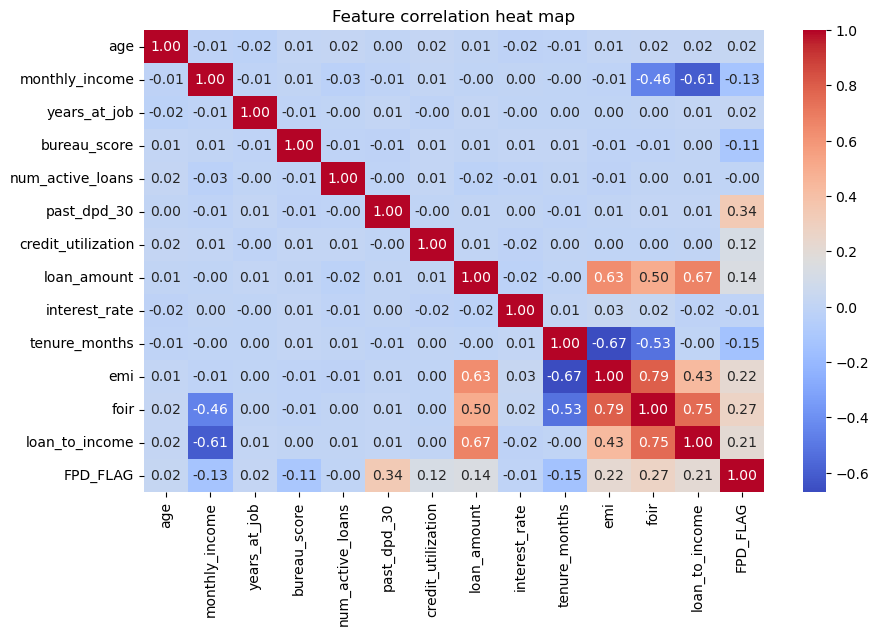

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature correlation heat map")
plt.show()

In [17]:
df.columns

Index(['loan_id', 'age', 'monthly_income', 'employment_type', 'years_at_job',
       'city_tier', 'bureau_score', 'num_active_loans', 'past_dpd_30',
       'credit_utilization', 'loan_amount', 'interest_rate', 'tenure_months',
       'emi', 'foir', 'loan_to_income', 'FPD_FLAG', 'score_band', 'foir_band'],
      dtype='object')

Feature engineering

In [18]:
features = [
    "age",
    "monthly_income",
    "employment_type",
    "years_at_job",
    "city_tier",
    "bureau_score",
    "num_active_loans",
    "past_dpd_30",
    "credit_utilization",
    "loan_amount",
    "interest_rate",
    "tenure_months",
    "foir",
    "loan_to_income"
]

In [19]:
X = df[features]
y = df["FPD_FLAG"]

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 10000 non-null  int32  
 1   monthly_income      10000 non-null  float64
 2   employment_type     10000 non-null  object 
 3   years_at_job        10000 non-null  int32  
 4   city_tier           10000 non-null  object 
 5   bureau_score        10000 non-null  float64
 6   num_active_loans    10000 non-null  int32  
 7   past_dpd_30         10000 non-null  int32  
 8   credit_utilization  10000 non-null  float64
 9   loan_amount         10000 non-null  float64
 10  interest_rate       10000 non-null  float64
 11  tenure_months       10000 non-null  int32  
 12  foir                10000 non-null  float64
 13  loan_to_income      10000 non-null  float64
dtypes: float64(7), int32(5), object(2)
memory usage: 898.6+ KB


Encode categorical variables

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
X.head()

,age,monthly_income,years_at_job,bureau_score,num_active_loans,past_dpd_30,credit_utilization,loan_amount,interest_rate,tenure_months,foir,loan_to_income,employment_type_self_employed,city_tier_tier2,city_tier_tier3
0,59,77313.480137,10,678.170368,0,0,0.593077,244688.955675,15.529005,48,0.106892,0.263741,False,True,False
1,49,59969.582444,12,623.669208,3,1,0.232975,112084.839190,14.070688,12,0.177668,0.155752,True,True,False
2,35,46684.333284,10,783.246960,2,0,0.029162,246468.771643,16.045854,24,0.290573,0.439956,True,True,False
3,28,36239.505063,2,643.954801,2,1,0.195198,188027.588863,14.860045,12,0.496623,0.432373,False,False,False
4,41,44668.829138,1,696.991839,0,0,0.033303,304194.041438,11.097440,24,0.346727,0.567499,False,True,False


Train test split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

Feature scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the Model

In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Predict Proba

In [26]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

Evaluation

ROC AUC

In [27]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,y_prob)

print(auc)

0.7610638626874903


Confusion matrix

In [28]:
from sklearn.metrics import confusion_matrix

y_pred = log_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[ 404 1481]
 [ 144  971]]


e:\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Classification report

In [29]:
from sklearn.metrics import classification_report

cr = classification_report(y_test,y_pred)

print(cr)

              precision    recall  f1-score   support

           0       0.74      0.21      0.33      1885
           1       0.40      0.87      0.54      1115

    accuracy                           0.46      3000
   macro avg       0.57      0.54      0.44      3000
weighted avg       0.61      0.46      0.41      3000



KS

In [30]:
ks_df = pd.DataFrame({
    "actual": y_test,
    "prob": y_prob
})

In [31]:
ks_df.head()

,actual,prob
1185,0,0.180940
3819,0,0.259672
3444,0,0.377222
7297,0,0.248469
7618,1,0.901765


In [32]:
ks_df = ks_df.sort_values("prob", ascending=False)

In [33]:
ks_df.head()

,actual,prob
6790,1,0.998834
5222,1,0.998753
9473,1,0.997735
3182,1,0.997356
6795,1,0.997132


Create Decile

In [34]:
ks_df["decile"] = pd.qcut(
    ks_df['prob'],
    10,
    labels=False,
    duplicates='drop'
)

In [35]:
ks_table = ks_df.groupby("decile").agg(
    loans=("actual","count"),
    bad=("actual","sum")
)

ks_table["good"] = ks_table["loans"] - ks_table["bad"]
ks_table["bad_rate"] = ks_table["bad"] / ks_table["loans"]

In [36]:
ks_table = ks_table.sort_index(ascending=False)

ks_table["cum_bad"] = ks_table["bad"].cumsum() / ks_table["bad"].sum()
ks_table["cum_good"] = ks_table["good"].cumsum() / ks_table["good"].sum()

ks_table["ks"] = abs(ks_table["cum_bad"] - ks_table["cum_good"])

In [37]:
ks_value = ks_table["ks"].max()

print("KS:", ks_value)

KS: 0.4010895552568662


In [38]:
ks_table

,loans,bad,good,bad_rate,cum_bad,cum_good,ks
decile,,,,,,,
9,300,248,52,0.826667,0.222422,0.027586,0.194835
8,300,190,110,0.633333,0.392825,0.085942,0.306883
7,300,155,145,0.516667,0.531839,0.162865,0.368974
6,300,134,166,0.446667,0.652018,0.250928,0.401090
5,300,89,211,0.296667,0.731839,0.362865,0.368974
4,300,96,204,0.320000,0.817937,0.471088,0.346850
3,300,64,236,0.213333,0.875336,0.596286,0.279050
2,300,60,240,0.200000,0.929148,0.723607,0.205541
1,300,41,259,0.136667,0.965919,0.861008,0.104911


Check IV

In [39]:
import scorecardpy as sc

In [40]:
iv = sc.iv(df,y="FPD_FLAG")

e:\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 1 ... 0 1 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)


In [41]:
print(iv)

              variable  info_value
16         past_dpd_30    0.521664
4            foir_band    0.314620
5        tenure_months    0.110192
2      employment_type    0.085609
7           score_band    0.054640
10         loan_amount    0.016315
8                  age    0.016018
14        bureau_score    0.015385
12      monthly_income    0.014235
1       loan_to_income    0.010448
0              loan_id    0.010362
3   credit_utilization    0.010362
6                  emi    0.010362
13       interest_rate    0.010362
9                 foir    0.010362
17        years_at_job    0.006798
15    num_active_loans    0.004531
11           city_tier    0.000386


WOE

Remove unique identifiers before WOE

In [42]:
df.columns

Index(['loan_id', 'age', 'monthly_income', 'employment_type', 'years_at_job',
       'city_tier', 'bureau_score', 'num_active_loans', 'past_dpd_30',
       'credit_utilization', 'loan_amount', 'interest_rate', 'tenure_months',
       'emi', 'foir', 'loan_to_income', 'FPD_FLAG', 'score_band', 'foir_band'],
      dtype='object')

In [43]:
df_model = df.drop(columns="loan_id")

converts categorical variables to string/object

In [44]:
df_model = df_model.copy()

for col in df_model.select_dtypes(include=["category"]).columns:
    df_model[col] = df_model[col].astype(str)

In [45]:
bins = sc.woebin(df_model,y="FPD_FLAG")

df_woe = sc.woebin_ply(df_model,bins)

[INFO] creating woe binning ...


e:\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 1 ... 0 1 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
e:\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
e:\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  dat

[INFO] converting into woe values ...


In [46]:
df_woe.head()

,FPD_FLAG,tenure_months_woe,emi_woe,foir_band_woe,score_band_woe,age_woe,foir_woe,loan_amount_woe,city_tier_woe,loan_to_income_woe,monthly_income_woe,employment_type_woe,interest_rate_woe,bureau_score_woe,num_active_loans_woe,credit_utilization_woe,past_dpd_30_woe,years_at_job_woe
0,1,-0.323491,0.009422,-0.392700,0.027988,0.103099,-0.461452,0.115681,0.012484,-0.113012,-0.310789,-0.203384,0.004996,-0.075010,0.071219,0.435858,-0.554916,0.020635
1,1,0.536926,0.009422,-0.392700,0.387647,0.012397,-0.197354,-0.474020,0.012484,-0.511816,-0.023515,0.423939,0.008240,0.294357,0.074514,-0.189062,0.491881,0.020635
2,1,-0.127935,0.009422,-0.048608,-0.307215,-0.039850,0.122691,0.115681,0.012484,0.091211,-0.023515,0.423939,0.004996,-0.349325,0.013313,-0.358801,-0.554916,0.020635
3,1,0.536926,0.607586,0.575256,0.387647,-0.050082,0.699366,0.115681,0.007301,0.091211,-0.023515,-0.203384,0.008240,0.294357,0.013313,-0.189062,0.491881,-0.027635
4,0,-0.127935,0.009422,0.255230,0.027988,0.012397,0.122691,0.429621,0.012484,0.302873,-0.023515,-0.203384,0.008081,-0.075010,0.071219,-0.358801,-0.554916,-0.127631


In [47]:
X = df_woe.drop(columns="FPD_FLAG")
y = df_woe["FPD_FLAG"]

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [49]:
log_model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [50]:
y_pred_prob = log_model.predict_proba(X_test)[:,1]

In [51]:
auc = roc_auc_score(y_test,y_pred_prob)

print(auc)

0.7667623794173972


There is no much improvement after WOE so moving to another models

Random Forest

In [52]:
X = df_model.drop(columns=["FPD_FLAG"])
y = df_model["FPD_FLAG"]

In [53]:
X = pd.get_dummies(X,drop_first=True)

In [54]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, n_estimators=300, random_state=42)

In [56]:
rf_pred_prob = rf_model.predict_proba(X_test)[:,1]

In [57]:
auc = roc_auc_score(y_test,rf_pred_prob)
print(auc)

0.7524473361801336


In [58]:
rf_pred = rf_model.predict(X_test)

In [59]:
confusion_matrix(y_test,rf_pred)

array([[1686,  199],
       [ 669,  446]], dtype=int64)

In [60]:
cr = classification_report(y_test,rf_pred)

print(cr)

              precision    recall  f1-score   support

           0       0.72      0.89      0.80      1885
           1       0.69      0.40      0.51      1115

    accuracy                           0.71      3000
   macro avg       0.70      0.65      0.65      3000
weighted avg       0.71      0.71      0.69      3000



Logistic regression is performing better than Random forest so moving to next model

XGBoost

In [61]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 400,
    max_depth = 4,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [62]:
xgb_pred_prob = xgb_model.predict_proba(X_test)[:,1]

In [63]:
auc = roc_auc_score(y_test,xgb_pred_prob)

print(auc)

0.7520943012453758


In [64]:
xgb_pred = xgb_model.predict(X_test)

In [65]:
confusion_matrix(y_test,xgb_pred)

array([[1616,  269],
       [ 571,  544]], dtype=int64)

In [66]:
cr = classification_report(y_test,xgb_pred)

print(cr)

              precision    recall  f1-score   support

           0       0.74      0.86      0.79      1885
           1       0.67      0.49      0.56      1115

    accuracy                           0.72      3000
   macro avg       0.70      0.67      0.68      3000
weighted avg       0.71      0.72      0.71      3000



Logistic regression has best performance compared to other models 

Save Log model

In [67]:
import joblib

joblib.dump(log_model,'log_model.pkl')

['log_model.pkl']

Running the final model on simulated dataset to replicate like real life scenario

Simulated Dataset

In [68]:
log_model = joblib.load("log_model.pkl")

In [69]:
df_input = pd.DataFrame({
    "loan_id":df["loan_id"]
})

df_input["APPLICATION_DATE"] = pd.Timestamp.today()

In [70]:
df_input.head()

,loan_id,APPLICATION_DATE
0,LN000001,2026-03-20 13:15:09.801344
1,LN000002,2026-03-20 13:15:09.801344
2,LN000003,2026-03-20 13:15:09.801344
3,LN000004,2026-03-20 13:15:09.801344
4,LN000005,2026-03-20 13:15:09.801344


Joining with feature

In [71]:
df_model.head()

,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,credit_utilization,loan_amount,interest_rate,tenure_months,emi,foir,loan_to_income,FPD_FLAG,score_band,foir_band
0,59,77313.480137,salaried,10,tier2,678.170368,0,0,0.593077,244688.955675,15.529005,48,8264.166645,0.106892,0.263741,1,650-700,0-20%
1,49,59969.582444,self_employed,12,tier2,623.669208,3,1,0.232975,112084.839190,14.070688,12,10654.662280,0.177668,0.155752,1,600-650,0-20%
2,35,46684.333284,self_employed,10,tier2,783.246960,2,0,0.029162,246468.771643,16.045854,24,13565.200341,0.290573,0.439956,1,750+,20-30%
3,28,36239.505063,salaried,2,metro,643.954801,2,1,0.195198,188027.588863,14.860045,12,17997.381050,0.496623,0.432373,1,600-650,40-50%
4,41,44668.829138,salaried,1,tier2,696.991839,0,0,0.033303,304194.041438,11.097440,24,15487.897565,0.346727,0.567499,0,650-700,30-40%


In [72]:
df_scoring_base = df_input.merge(df,on='loan_id',how='left')

In [73]:
df_scoring_base.head()

,loan_id,APPLICATION_DATE,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,credit_utilization,loan_amount,interest_rate,tenure_months,emi,foir,loan_to_income,FPD_FLAG,score_band,foir_band
0,LN000001,2026-03-20 13:15:09.801344,59,77313.480137,salaried,10,tier2,678.170368,0,0,0.593077,244688.955675,15.529005,48,8264.166645,0.106892,0.263741,1,650-700,0-20%
1,LN000002,2026-03-20 13:15:09.801344,49,59969.582444,self_employed,12,tier2,623.669208,3,1,0.232975,112084.839190,14.070688,12,10654.662280,0.177668,0.155752,1,600-650,0-20%
2,LN000003,2026-03-20 13:15:09.801344,35,46684.333284,self_employed,10,tier2,783.246960,2,0,0.029162,246468.771643,16.045854,24,13565.200341,0.290573,0.439956,1,750+,20-30%
3,LN000004,2026-03-20 13:15:09.801344,28,36239.505063,salaried,2,metro,643.954801,2,1,0.195198,188027.588863,14.860045,12,17997.381050,0.496623,0.432373,1,600-650,40-50%
4,LN000005,2026-03-20 13:15:09.801344,41,44668.829138,salaried,1,tier2,696.991839,0,0,0.033303,304194.041438,11.097440,24,15487.897565,0.346727,0.567499,0,650-700,30-40%


Apply WOE

In [74]:
df_woe = sc.woebin_ply(df_scoring_base,bins)

[INFO] converting into woe values ...


In [75]:
X = df_woe.drop(columns="FPD_FLAG")
y = df_woe["FPD_FLAG"]

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [77]:
train_cols = X_train.columns

In [78]:
train_cols = train_cols.drop(['APPLICATION_DATE', 'loan_id'])

In [79]:
X_scoring = df_woe[train_cols]

In [80]:
X_scoring = X_scoring.fillna(0)

In [81]:
df_scoring_base["PRED_PROB"] = log_model.predict_proba(X_scoring)[:,1]

In [82]:
df_scoring_base.head()

,loan_id,APPLICATION_DATE,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,...,loan_amount,interest_rate,tenure_months,emi,foir,loan_to_income,FPD_FLAG,score_band,foir_band,PRED_PROB
0,LN000001,2026-03-20 13:15:09.801344,59,77313.480137,salaried,10,tier2,678.170368,0,0,...,244688.955675,15.529005,48,8264.166645,0.106892,0.263741,1,650-700,0-20%,0.297495
1,LN000002,2026-03-20 13:15:09.801344,49,59969.582444,self_employed,12,tier2,623.669208,3,1,...,112084.839190,14.070688,12,10654.662280,0.177668,0.155752,1,600-650,0-20%,0.745687
2,LN000003,2026-03-20 13:15:09.801344,35,46684.333284,self_employed,10,tier2,783.246960,2,0,...,246468.771643,16.045854,24,13565.200341,0.290573,0.439956,1,750+,20-30%,0.272459
3,LN000004,2026-03-20 13:15:09.801344,28,36239.505063,salaried,2,metro,643.954801,2,1,...,188027.588863,14.860045,12,17997.381050,0.496623,0.432373,1,600-650,40-50%,0.769603
4,LN000005,2026-03-20 13:15:09.801344,41,44668.829138,salaried,1,tier2,696.991839,0,0,...,304194.041438,11.097440,24,15487.897565,0.346727,0.567499,0,650-700,30-40%,0.208615


Deciling

In [83]:
df_scoring_base["SCORE"] = pd.cut(
    df_scoring_base["PRED_PROB"],
    10,
    labels=[10,9,8,7,6,5,4,3,2,1]
)

Risk band

In [84]:
def risk_band(score):
    if score >= 8:
        return "Low Risk"
    elif score >=5:
        return "Medium Risk"
    elif score >= 3:
        return "High Risk"
    else:
        return "Very High Risk"

df_scoring_base["RISK_BAND"] = df_scoring_base["SCORE"].astype(int).apply(risk_band)

In [85]:
df_scoring_base.head()

,loan_id,APPLICATION_DATE,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,...,tenure_months,emi,foir,loan_to_income,FPD_FLAG,score_band,foir_band,PRED_PROB,SCORE,RISK_BAND
0,LN000001,2026-03-20 13:15:09.801344,59,77313.480137,salaried,10,tier2,678.170368,0,0,...,48,8264.166645,0.106892,0.263741,1,650-700,0-20%,0.297495,8,Low Risk
1,LN000002,2026-03-20 13:15:09.801344,49,59969.582444,self_employed,12,tier2,623.669208,3,1,...,12,10654.662280,0.177668,0.155752,1,600-650,0-20%,0.745687,3,High Risk
2,LN000003,2026-03-20 13:15:09.801344,35,46684.333284,self_employed,10,tier2,783.246960,2,0,...,24,13565.200341,0.290573,0.439956,1,750+,20-30%,0.272459,8,Low Risk
3,LN000004,2026-03-20 13:15:09.801344,28,36239.505063,salaried,2,metro,643.954801,2,1,...,12,17997.381050,0.496623,0.432373,1,600-650,40-50%,0.769603,3,High Risk
4,LN000005,2026-03-20 13:15:09.801344,41,44668.829138,salaried,1,tier2,696.991839,0,0,...,24,15487.897565,0.346727,0.567499,0,650-700,30-40%,0.208615,9,Low Risk


Risk Band

In [86]:
def decision(band):
    if band == "Low Risk":
        return "Approve"
    elif band == "Medium Risk":
        return "Approve with Conditions"
    elif band == "High Risk":
        return "Manual Review"
    else:
        return "Reject"

df_scoring_base["DECISION"] = df_scoring_base["RISK_BAND"].apply(decision)

In [87]:
final_output = df_scoring_base[[
    "loan_id",
    "PRED_PROB",
    "SCORE",
    "RISK_BAND",
    "DECISION"
]]

final_output["SCORING_DATE"] = pd.Timestamp.today()
final_output["MODEL_VERSION"] = "FPD_LOGISTIC_V1"

C:\Users\user\AppData\Local\Temp\ipykernel_12160\635967573.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_output["SCORING_DATE"] = pd.Timestamp.today()
C:\Users\user\AppData\Local\Temp\ipykernel_12160\635967573.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_output["MODEL_VERSION"] = "FPD_LOGISTIC_V1"


In [88]:
final_output.head()

,loan_id,PRED_PROB,SCORE,RISK_BAND,DECISION,SCORING_DATE,MODEL_VERSION
0,LN000001,0.297495,8,Low Risk,Approve,2026-03-20 13:15:11.052051,FPD_LOGISTIC_V1
1,LN000002,0.745687,3,High Risk,Manual Review,2026-03-20 13:15:11.052051,FPD_LOGISTIC_V1
2,LN000003,0.272459,8,Low Risk,Approve,2026-03-20 13:15:11.052051,FPD_LOGISTIC_V1
3,LN000004,0.769603,3,High Risk,Manual Review,2026-03-20 13:15:11.052051,FPD_LOGISTIC_V1
4,LN000005,0.208615,9,Low Risk,Approve,2026-03-20 13:15:11.052051,FPD_LOGISTIC_V1


Lift Chart

In [112]:
df_lift = df_scoring_base.copy()

In [113]:
df_lift["actual"] = df_lift["FPD_FLAG"]
df_lift["prob"] = df_lift["PRED_PROB"]

In [114]:
df_lift = df_lift.sort_values(by="prob",ascending=False)

In [115]:
df_lift.head()

,loan_id,APPLICATION_DATE,age,monthly_income,employment_type,years_at_job,city_tier,bureau_score,num_active_loans,past_dpd_30,...,loan_to_income,FPD_FLAG,score_band,foir_band,PRED_PROB,SCORE,RISK_BAND,DECISION,actual,prob
8104,LN008105,2026-03-20 13:15:09.801344,40,20622.179942,salaried,5,tier3,604.980487,1,2,...,0.803178,1,600-650,50%+,0.993721,1,Very High Risk,Reject,1,0.993721
4251,LN004252,2026-03-20 13:15:09.801344,51,46119.316589,self_employed,3,metro,712.693157,2,2,...,0.497471,1,700-750,50%+,0.991397,1,Very High Risk,Reject,1,0.991397
7403,LN007404,2026-03-20 13:15:09.801344,51,37904.693335,self_employed,7,tier2,641.098655,3,2,...,0.718797,1,600-650,50%+,0.990855,1,Very High Risk,Reject,1,0.990855
253,LN000254,2026-03-20 13:15:09.801344,56,55748.776887,self_employed,9,metro,795.432499,1,2,...,0.553145,1,750+,50%+,0.990111,1,Very High Risk,Reject,1,0.990111
5253,LN005254,2026-03-20 13:15:09.801344,54,27835.555115,self_employed,9,tier2,712.790974,2,2,...,0.710678,1,700-750,50%+,0.989051,1,Very High Risk,Reject,1,0.989051


Create decile

In [116]:
df_lift["decile"]= pd.qcut(
    df_lift["prob"],
    10,
    labels=False,
    duplicates="drop"
)+1

In [117]:
df_lift["decile"] = 10-df_lift["decile"]

Agg metrics

In [118]:
lift_table = df_lift.groupby("decile").agg(
    total = ("actual","count"),
    bads = ("actual","sum")
).reset_index()

In [119]:
lift_table

,decile,total,bads
0,0,1000,856
1,1,1000,667
2,2,1000,551
3,3,1000,430
4,4,1000,348
5,5,1000,272
6,6,1000,211
7,7,1000,163
8,8,1000,132
9,9,1000,87


In [120]:
lift_table["bad_rate"] = lift_table["bads"]/lift_table["total"]

In [121]:
lift_table["cum_bads"] = lift_table["bads"].cumsum()
lift_table["cum_total"] = lift_table["total"].cumsum()

In [122]:
total_bads = lift_table["bads"].sum()

In [123]:
lift_table["cum_bads_pct"]= lift_table["cum_bads"]/total_bads

Plot lift curve

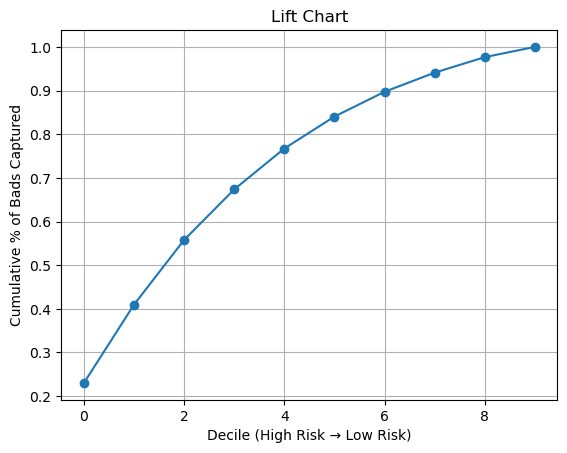

In [124]:
import matplotlib.pyplot as plt

plt.plot(lift_table["decile"], lift_table["cum_bads_pct"], marker='o')
plt.xlabel("Decile (High Risk → Low Risk)")
plt.ylabel("Cumulative % of Bads Captured")
plt.title("Lift Chart")
plt.grid()
plt.show()